In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import time

## day 1

In [2]:
G = nx.Graph()

In [3]:
nodes = ['a', 'c', 'd', 'b', 'e', 'f', 'g']
G.add_nodes_from(nodes)

# Add edges to the graph
edges = [
         ('c', 'a',  23),
         ('a', 'b',  20),
         ('b', 'c',  45),
         ('d', 'a',  56),
         ('d', 'c',  99),
         ('d', 'b',  0), 
         ('e', 'a',  90),
         ('e', 'f', 213),
         ('f', 'g', 987),
         ('g', 'e', 7)
        ]

G.add_weighted_edges_from(edges)

# Print some basic information about the graph
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Nodes in the graph:", G.nodes())
print("Edges in the graph:", G.edges(data=True))

Number of nodes: 7
Number of edges: 10
Nodes in the graph: ['a', 'c', 'd', 'b', 'e', 'f', 'g']
Edges in the graph: [('a', 'c', {'weight': 23}), ('a', 'b', {'weight': 20}), ('a', 'd', {'weight': 56}), ('a', 'e', {'weight': 90}), ('c', 'b', {'weight': 45}), ('c', 'd', {'weight': 99}), ('d', 'b', {'weight': 0}), ('e', 'f', {'weight': 213}), ('e', 'g', {'weight': 7}), ('f', 'g', {'weight': 987})]


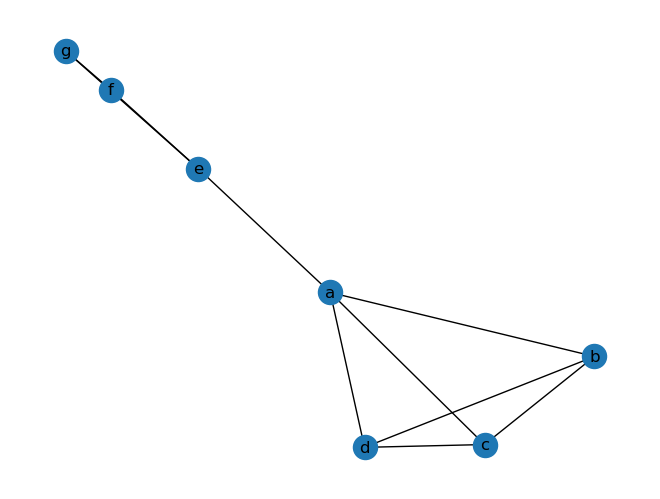

In [4]:
nx.draw(G, with_labels = True)

In [5]:
bfs_nodes = list(nx.bfs_tree(G, source='c'))
print(bfs_nodes)

['c', 'a', 'b', 'd', 'e', 'f', 'g']


In [6]:
dfs_nodes = list(nx.dfs_preorder_nodes(G, source='a'))
print(dfs_nodes)

['a', 'c', 'b', 'd', 'e', 'f', 'g']


In [7]:
try:
    cycle = nx.algorithms.cycles.find_cycle(G)
    has_cycles = True
except nx.NetworkXNoCycle:
    has_cycles = False
    
if(has_cycles):
    print("cyclic")
else:
    print("not cyclic")

cyclic


## day-2

### path finding!!

In [8]:
shortest_path_bfs = nx.shortest_path(G, source= 'a', target= 'd')
print(shortest_path_bfs)

['a', 'd']


In [9]:
shortest_path_dijkstra = nx.shortest_path(G, source= 'a', target= 'd' , weight = 'weight',method='dijkstra')
print(shortest_path_dijkstra)

['a', 'b', 'd']


In [10]:
shortest_path_uniform_cost_search = nx.shortest_path(G, source= 'a', target= 'd' , weight = 'weight')
print(shortest_path_uniform_cost_search) 

['a', 'b', 'd']


In [11]:
shortest_path_bellmen_ford = nx.shortest_path(G, source= 'a', target= 'd' , weight = 'weight',method='bellman-ford')
print(shortest_path_bellmen_ford)

['a', 'b', 'd']


In [12]:
def dist(a,b):
    return ord(a)-ord(b)
shortest_path_a_star = nx.astar_path(G, 'a', 'd', heuristic=dist, weight="cost")
print(shortest_path_a_star)

['a', 'd']


In [13]:
single_source_shortest_paths_bfs=nx.single_source_shortest_path(G,'a')
print(single_source_shortest_paths_bfs)

{'a': ['a'], 'c': ['a', 'c'], 'b': ['a', 'b'], 'd': ['a', 'd'], 'e': ['a', 'e'], 'f': ['a', 'e', 'f'], 'g': ['a', 'e', 'g']}


In [14]:
single_source_shortest_paths_dijkstra = nx.single_source_dijkstra_path(G, 'a')
print(single_source_shortest_paths_dijkstra)

{'a': ['a'], 'c': ['a', 'c'], 'b': ['a', 'b'], 'd': ['a', 'b', 'd'], 'e': ['a', 'e'], 'f': ['a', 'e', 'f'], 'g': ['a', 'e', 'g']}


In [15]:
single_source_shortest_paths_bellman_ford = nx.single_source_bellman_ford_path(G,'a')
print(single_source_shortest_paths_bellman_ford)

{'a': ['a'], 'c': ['a', 'c'], 'b': ['a', 'b'], 'd': ['a', 'b', 'd'], 'e': ['a', 'e'], 'f': ['a', 'e', 'f'], 'g': ['a', 'e', 'g']}


## day-3

In [16]:
all_pairs_shortest_path_bfs = dict(nx.all_pairs_shortest_path_length(G))
print(all_pairs_shortest_path_bfs)

{'a': {'a': 0, 'c': 1, 'b': 1, 'd': 1, 'e': 1, 'f': 2, 'g': 2}, 'c': {'c': 0, 'a': 1, 'b': 1, 'd': 1, 'e': 2, 'f': 3, 'g': 3}, 'd': {'d': 0, 'a': 1, 'c': 1, 'b': 1, 'e': 2, 'f': 3, 'g': 3}, 'b': {'b': 0, 'a': 1, 'c': 1, 'd': 1, 'e': 2, 'f': 3, 'g': 3}, 'e': {'e': 0, 'a': 1, 'f': 1, 'g': 1, 'c': 2, 'b': 2, 'd': 2}, 'f': {'f': 0, 'e': 1, 'g': 1, 'a': 2, 'c': 3, 'b': 3, 'd': 3}, 'g': {'g': 0, 'f': 1, 'e': 1, 'a': 2, 'c': 3, 'b': 3, 'd': 3}}


In [17]:
all_pairs_shortest_path_bfs['a']['b']

1

In [18]:
all_pairs_shortest_path_dijkstra = dict(nx.all_pairs_dijkstra_path(G,weight = "weight"))
for i in all_pairs_shortest_path_dijkstra.keys():
    print("source :",i," ---------------" )
    for j in all_pairs_shortest_path_dijkstra[i]:
        print("dest : " ,j , " :::: ", end = " ")
        for node in all_pairs_shortest_path_dijkstra[i][j]:
            print(node, end = "")
        print()

source : a  ---------------
dest :  a  ::::  a
dest :  c  ::::  ac
dest :  b  ::::  ab
dest :  d  ::::  abd
dest :  e  ::::  ae
dest :  f  ::::  aef
dest :  g  ::::  aeg
source : c  ---------------
dest :  c  ::::  c
dest :  a  ::::  ca
dest :  b  ::::  cab
dest :  d  ::::  cabd
dest :  e  ::::  cae
dest :  f  ::::  caef
dest :  g  ::::  caeg
source : d  ---------------
dest :  d  ::::  d
dest :  a  ::::  dba
dest :  c  ::::  dbac
dest :  b  ::::  db
dest :  e  ::::  dbae
dest :  f  ::::  dbaef
dest :  g  ::::  dbaeg
source : b  ---------------
dest :  b  ::::  b
dest :  a  ::::  ba
dest :  c  ::::  bac
dest :  d  ::::  bd
dest :  e  ::::  bae
dest :  f  ::::  baef
dest :  g  ::::  baeg
source : e  ---------------
dest :  e  ::::  e
dest :  a  ::::  ea
dest :  f  ::::  ef
dest :  g  ::::  eg
dest :  c  ::::  eac
dest :  b  ::::  eab
dest :  d  ::::  eabd
source : f  ---------------
dest :  f  ::::  f
dest :  e  ::::  fe
dest :  g  ::::  feg
dest :  a  ::::  fea
dest :  c  ::::  feac
de

In [19]:
all_pairs_shortest_path_bellman_ford = dict(nx.all_pairs_bellman_ford_path(G,weight = "weight"))
for i in all_pairs_shortest_path_bellman_ford.keys():
    print("source :",i," ---------------" )
    for j in all_pairs_shortest_path_bellman_ford[i]:
        print("dest : " ,j , " :::: ", end = " ")
        for node in all_pairs_shortest_path_bellman_ford[i][j]:
            print(node, end = "")
        print()

source : a  ---------------
dest :  a  ::::  a
dest :  c  ::::  ac
dest :  b  ::::  ab
dest :  d  ::::  abd
dest :  e  ::::  ae
dest :  f  ::::  aef
dest :  g  ::::  aeg
source : c  ---------------
dest :  c  ::::  c
dest :  a  ::::  ca
dest :  b  ::::  cab
dest :  d  ::::  cabd
dest :  e  ::::  cae
dest :  f  ::::  caef
dest :  g  ::::  caeg
source : d  ---------------
dest :  d  ::::  d
dest :  a  ::::  dba
dest :  c  ::::  dbac
dest :  b  ::::  db
dest :  e  ::::  dbae
dest :  f  ::::  dbaef
dest :  g  ::::  dbaeg
source : b  ---------------
dest :  b  ::::  b
dest :  a  ::::  ba
dest :  c  ::::  bac
dest :  d  ::::  bd
dest :  e  ::::  bae
dest :  f  ::::  baef
dest :  g  ::::  baeg
source : e  ---------------
dest :  e  ::::  e
dest :  a  ::::  ea
dest :  f  ::::  ef
dest :  g  ::::  eg
dest :  c  ::::  eac
dest :  b  ::::  eab
dest :  d  ::::  eabd
source : f  ---------------
dest :  f  ::::  f
dest :  e  ::::  fe
dest :  g  ::::  feg
dest :  a  ::::  fea
dest :  c  ::::  feac
de

In [20]:
all_pairs_shortest_path_jhonson = nx.johnson(G, weight="weight")
for i in all_pairs_shortest_path_jhonson.keys():
    print("source :",i," ---------------" )
    for j in all_pairs_shortest_path_jhonson[i]:
        print("dest : " ,j , " :::: ", end = " ")
        for node in all_pairs_shortest_path_jhonson[i][j]:
            print(node, end = "")
        print()

source : a  ---------------
dest :  a  ::::  a
dest :  c  ::::  ac
dest :  b  ::::  ab
dest :  d  ::::  abd
dest :  e  ::::  ae
dest :  f  ::::  aef
dest :  g  ::::  aeg
source : c  ---------------
dest :  c  ::::  c
dest :  a  ::::  ca
dest :  b  ::::  cab
dest :  d  ::::  cabd
dest :  e  ::::  cae
dest :  f  ::::  caef
dest :  g  ::::  caeg
source : d  ---------------
dest :  d  ::::  d
dest :  a  ::::  dba
dest :  c  ::::  dbac
dest :  b  ::::  db
dest :  e  ::::  dbae
dest :  f  ::::  dbaef
dest :  g  ::::  dbaeg
source : b  ---------------
dest :  b  ::::  b
dest :  a  ::::  ba
dest :  c  ::::  bac
dest :  d  ::::  bd
dest :  e  ::::  bae
dest :  f  ::::  baef
dest :  g  ::::  baeg
source : e  ---------------
dest :  e  ::::  e
dest :  a  ::::  ea
dest :  f  ::::  ef
dest :  g  ::::  eg
dest :  c  ::::  eac
dest :  b  ::::  eab
dest :  d  ::::  eabd
source : f  ---------------
dest :  f  ::::  f
dest :  e  ::::  fe
dest :  g  ::::  feg
dest :  a  ::::  fea
dest :  c  ::::  feac
de

### minimum spanning trees

In [21]:
mst_kruskal = list(nx.algorithms.tree.minimum_spanning_edges(G, algorithm="kruskal",weight = "weight", data=True))
sorted(mst_kruskal)

[('a', 'b', {'weight': 20}),
 ('a', 'c', {'weight': 23}),
 ('a', 'e', {'weight': 90}),
 ('d', 'b', {'weight': 0}),
 ('e', 'f', {'weight': 213}),
 ('e', 'g', {'weight': 7})]

In [22]:
mst_prim = list(nx.algorithms.tree.minimum_spanning_edges(G, algorithm="prim",weight = "weight", data=True))
sorted(mst_prim)

[('a', 'b', {'weight': 20}),
 ('a', 'c', {'weight': 23}),
 ('b', 'd', {'weight': 0}),
 ('e', 'a', {'weight': 90}),
 ('e', 'f', {'weight': 213}),
 ('e', 'g', {'weight': 7})]

In [23]:
mst_boruvka = list(nx.algorithms.tree.minimum_spanning_edges(G, algorithm="boruvka",weight = "weight", data=True))
sorted(mst_boruvka)

[('a', 'b', {'weight': 20}),
 ('a', 'e', {'weight': 90}),
 ('c', 'a', {'weight': 23}),
 ('d', 'b', {'weight': 0}),
 ('e', 'g', {'weight': 7}),
 ('f', 'e', {'weight': 213})]

### topological sort

In [24]:
G_topo = nx.DiGraph()

In [25]:
nodes = ['a', 'c', 'd', 'b', 'e', 'f', 'g']
G_topo.add_nodes_from(nodes)

# Add edges to the graph
edges = [('c', 'a',  23),
         ('a', 'b',  20),
         ('d', 'a',  56),
         ('e', 'a',  90),
         ('e', 'f', 213),
         ('f', 'g', 987),]

G_topo.add_weighted_edges_from(edges)

# Print some basic information about the graph
print("Number of nodes:", G_topo.number_of_nodes())
print("Number of edges:", G_topo.number_of_edges())
print("Nodes in the graph:", G_topo.nodes())
print("Edges in the graph:", G_topo.edges(data=True))

Number of nodes: 7
Number of edges: 6
Nodes in the graph: ['a', 'c', 'd', 'b', 'e', 'f', 'g']
Edges in the graph: [('a', 'b', {'weight': 20}), ('c', 'a', {'weight': 23}), ('d', 'a', {'weight': 56}), ('e', 'a', {'weight': 90}), ('e', 'f', {'weight': 213}), ('f', 'g', {'weight': 987})]


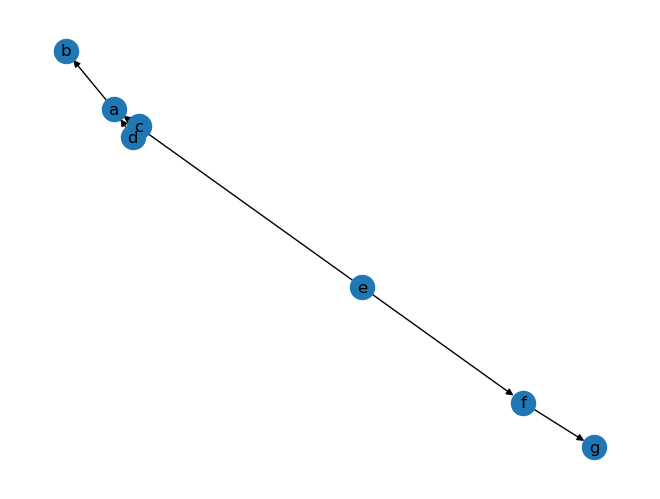

In [26]:
nx.draw(G_topo, with_labels = True)

In [27]:
toposort = list(nx.topological_sort(G_topo))
toposort

['c', 'd', 'e', 'a', 'f', 'b', 'g']

# day 4

### node and edge coloring

In [28]:
coloring = nx.coloring.greedy_color(G, strategy="largest_first")
for i in sorted(coloring):
    print(i, " ::: " , coloring[i])

a  :::  0
b  :::  3
c  :::  1
d  :::  2
e  :::  1
f  :::  0
g  :::  2


In [29]:
#edge_colors = nx.edge_coloring(graph, strategy="sequential")
#edge_colors

### is Bipartite

In [30]:
is_bipartite = nx.algorithms.bipartite.is_bipartite(G)
print(is_bipartite)

False


### articulation points

In [31]:
articulation_points = list(nx.articulation_points(G))
articulation_points

['e', 'a']

### Bridges

In [32]:
bridges = list(nx.bridges(G))
bridges

[('a', 'e')]

### eulerian_path

In [33]:
# graph for eulerian_path
G_eulerian_path = nx.Graph()

nodes = ['A', 'B', 'C', 'D', 'E', 'F']
G_eulerian_path.add_nodes_from(nodes)

# Add edges
edges = [('A', 'B'), ('A', 'D'), ('B', 'C'), ('B', 'E'), ('C', 'F'), ('D', 'E'), ('E', 'F')]
G_eulerian_path.add_edges_from(edges)

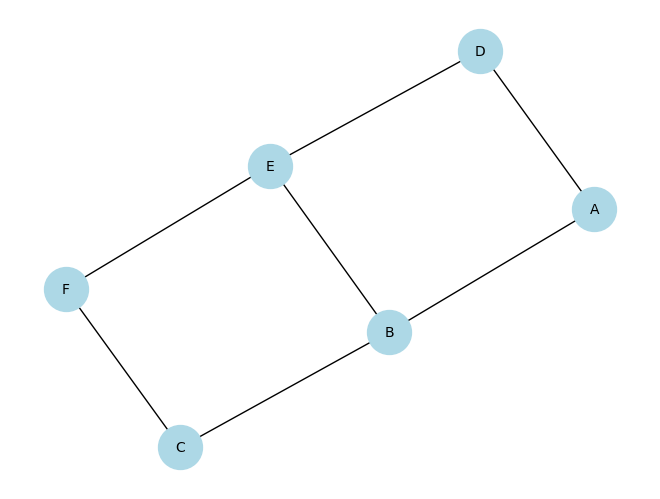

In [34]:
nx.draw(G_eulerian_path, with_labels=True, node_size=1000, node_color='lightblue', font_size=10, font_color='black')

In [35]:
eulerian_path = list(nx.eulerian_path(G_eulerian_path))
print(eulerian_path)

[('B', 'A'), ('A', 'D'), ('D', 'E'), ('E', 'B'), ('B', 'C'), ('C', 'F'), ('F', 'E')]


### the eulerian_circuit function from networkx is giving wrong answer

In [36]:
eulerian_circuit = list(nx.eulerian_path(G_eulerian_path))
print(eulerian_circuit)

[('B', 'A'), ('A', 'D'), ('D', 'E'), ('E', 'B'), ('B', 'C'), ('C', 'F'), ('F', 'E')]


### eulerian circuit testing

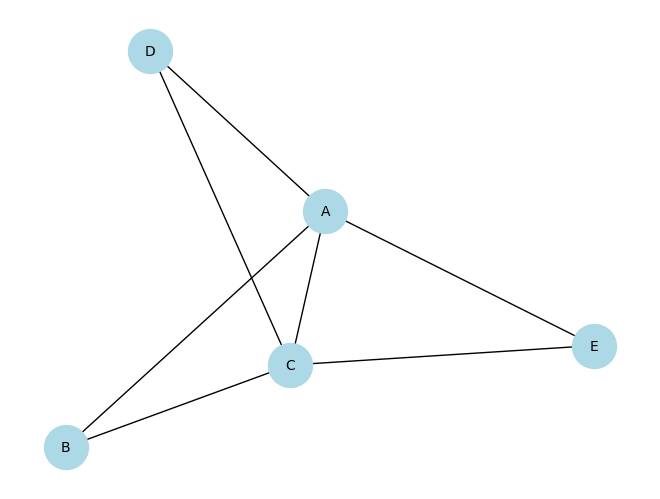

In [37]:
G_eulerian_circuit = nx.Graph()
nodes = ['A', 'B', 'C', 'D', 'E']
G_eulerian_circuit.add_nodes_from(nodes)
edges = [('A', 'B'), ('B', 'C'), ('C', 'D'), ('D', 'A'),('C','E'),('A','C'),('A','E')]
G_eulerian_circuit.add_edges_from(edges)
nx.draw(G_eulerian_circuit, with_labels=True, node_size=1000, node_color='lightblue', font_size=10, font_color='black')

In [38]:
eulerian_circuit = list(nx.eulerian_circuit(G_eulerian_circuit,'C'))
print("Eulerian Circuit:",eulerian_circuit)

Eulerian Circuit: [('C', 'E'), ('E', 'A'), ('A', 'D'), ('D', 'C'), ('C', 'B'), ('B', 'A'), ('A', 'C')]


### strongly connected graph, for both the classic , and kosaraju algorithm

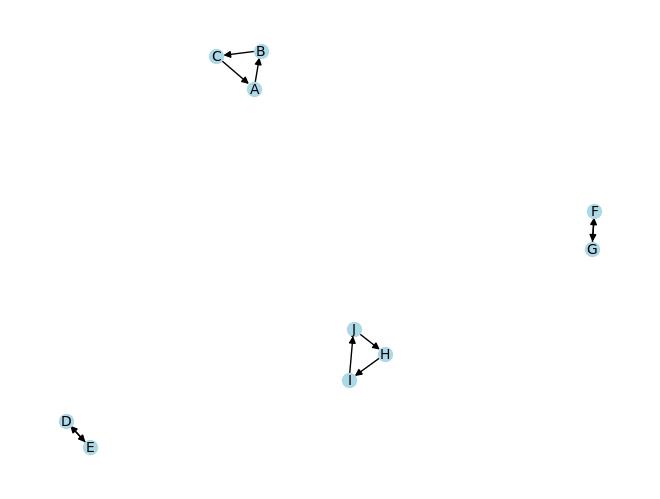

In [46]:
G_SCC = nx.DiGraph()
nodes = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']
G_SCC.add_nodes_from(nodes)

# Add edges to create the directed graph
edges = [('A', 'B'), ('B', 'C'), ('C', 'A'),
         ('D', 'E'), ('E', 'D'),
         ('F', 'G'), ('G', 'F'),
         ('H', 'I'), ('I', 'J'), ('J', 'H')]
G_SCC.add_edges_from(edges)
nx.draw(G_SCC, with_labels=True, node_size=100, node_color='lightblue', font_size=10, font_color='black')

In [49]:
SCC_classic = list(nx.strongly_connected_components(G_SCC))
SCC_classic

[{'A', 'B', 'C'}, {'D', 'E'}, {'F', 'G'}, {'H', 'I', 'J'}]

In [52]:
SCC_kosaraju = list(nx.kosaraju_strongly_connected_components(G_SCC))
SCC_kosaraju

[{'H', 'I', 'J'}, {'F', 'G'}, {'D', 'E'}, {'A', 'B', 'C'}]